In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
class LSTM_by_hand(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()

    self.input_size = input_size
    self.hidden_size = hidden_size

    combined_size = input_size + hidden_size


    # Forget gate: decides what to throw away from the cell state
    self.forget_gate = nn.Linear(combined_size, hidden_size)

    # Input gate: decides which new values to update in the cell state
    self.input_gate = nn.Linear(combined_size, hidden_size)

    # Candidate values: proposes new information to potentially add
    self.candidate_gate = nn.Linear(combined_size, hidden_size)

    # Output gate: decides what the new hidden state should be
    self.output_gate = nn.Linear(combined_size, hidden_size)


    # Maps the final hidden state to a single predicted price
    self.output_layer = nn.Linear(hidden_size, 1)


  def step(self, x_t, h_prev, c_prev):
    combined = torch.cat((x_t, h_prev), dim=1)

    f = torch.sigmoid(self.forget_gate(combined))
    i = torch.sigmoid(self.input_gate(combined))
    g = torch.tanh(self.candidate_gate(combined))
    o = torch.sigmoid(self.output_gate(combined))

    c_new = f * c_prev + i * g
    h_new = o * torch.tanh(c_new)

    return h_new, c_new

  def forward(self, x):
    # x shape: (batch_size, seq_len, input_size)
    batch_size, seq_len, _ = x.shape

    h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
    c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)

    for t in range(seq_len):
        x_t = x[:, t, :]                     # grab this time step's input, shape (batch_size, input_size)
        h_t, c_t = self.step(x_t, h_t, c_t)

    prediction = self.output_layer(h_t)   # shape: (batch_size, 1)

    return prediction


In [5]:
def training_step(model, x_train_data, y_train_data, loss_fn, optimizer_fn):
  model.train()

  y_train_pred = model(x_train_data)

  loss = loss_fn(y_train_pred, y_train_data)

  optimizer_fn.zero_grad()

  loss.backward()

  optimizer_fn.step()

  return loss.item()


In [6]:
def testing_step(model, x_test_data, y_test_data, loss_fn):
  model.eval()
  with torch.no_grad():

    y_test_pred = model(x_test_data)

    loss = loss_fn(y_test_pred, y_test_data)

  return loss.item()


In [7]:
def plot_loss_curves(epochs, train_losses, test_losses):
  plt.figure(figsize=(10, 7))
  # Create x-axis values based on the actual number of collected losses
  x_axis_epochs = range(0, len(train_losses) * 10, 10)
  plt.plot(x_axis_epochs, train_losses, label="Training Loss")
  plt.plot(x_axis_epochs, test_losses, label="Test Loss")
  plt.title("Loss Curves")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [8]:
def training_and_testing_loops(max_epochs, model, loss_fn, optimizer_fn, x_train, y_train, x_test, y_test):

  train_losses = []
  test_losses = []

  for epoch in range(max_epochs):

    train_loss = training_step(model, x_train, y_train, loss_fn, optimizer_fn)
    test_loss = testing_step(model, x_test, y_test, loss_fn)

    if epoch % 10 == 0:
      train_losses.append(train_loss)
      test_losses.append(test_loss)


  plot_loss_curves(epoch, train_losses, test_losses)
  print(f'final epoch: {epoch} | final train loss: {train_loss:.4f} | final test loss: {test_loss:.4f}')


In [11]:
from sklearn.model_selection import train_test_split

data = np.load("Top_9_S&P500_dataset.npz")
data_X = torch.tensor(data["X"], dtype=torch.float32)
data_y = torch.tensor(data["y"], dtype=torch.float32)

print(data_X.shape)
print(data_y.shape)

torch.Size([1764, 20, 13])
torch.Size([1764])


In [12]:
#turn dataset into test and train lists
split_ratio = 0.8
split_index = int(len(data_X) * split_ratio)

x_train = data_X[:split_index].to(device)
y_train = data_y[:split_index].unsqueeze(dim=1).to(device)
x_test = data_X[split_index:].to(device)
y_test = data_y[split_index:].unsqueeze(dim=1).to(device)


In [13]:
# @title model_1 declaration
model_1 = LSTM_by_hand(13, 64).to(device)

Optimizer = torch.optim.Adam(model_1.parameters(), lr = 0.005)

Loss_fn = nn.L1Loss()

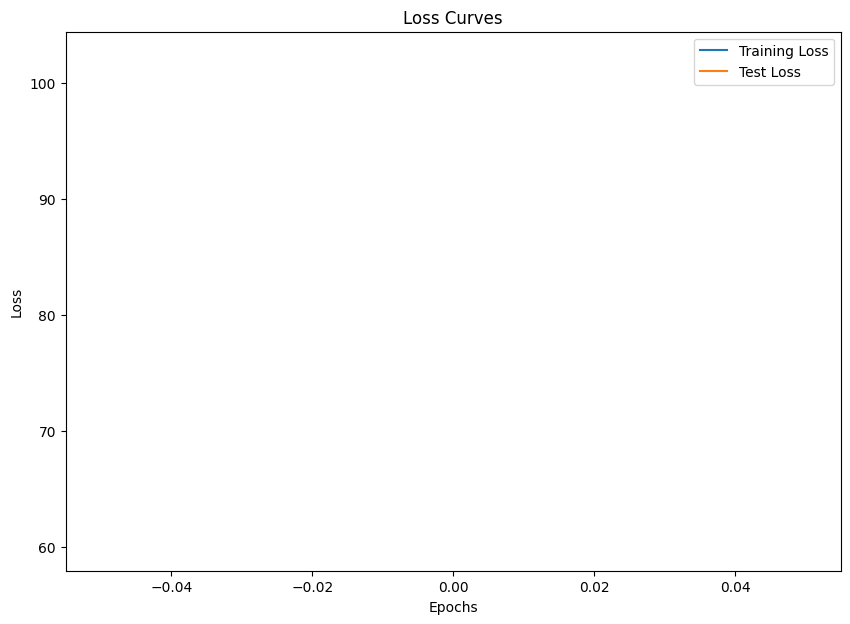

final epoch: 0 | final train loss: 102.3219 | final test loss: 60.0842


In [ ]:
# @title model_1 train/test
training_and_testing_loops(5000, model_1, Loss_fn, Optimizer, x_train, y_train, x_test, y_test)

In [ ]:
# @title model_1_0 declaration
model_1_0 = LSTM_by_hand(13, 64).to(device)

Optimizer = torch.optim.Adam(model_1_0.parameters(), lr = 0.005)

Loss_fn = nn.L1Loss()

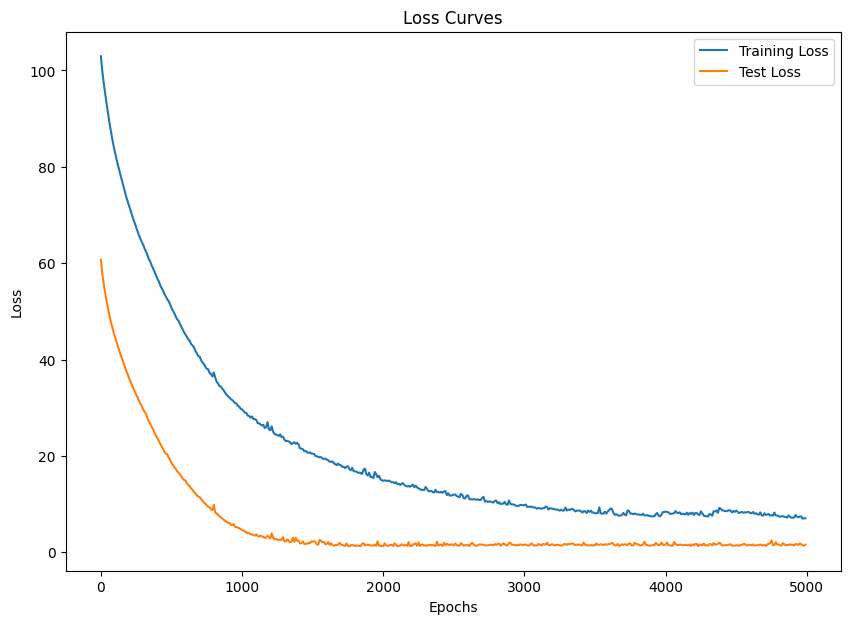

final epoch: 4999 | final train loss: 6.8499 | final test loss: 1.5664


In [ ]:
# @title model_1_0 train/test
training_and_testing_loops(5000, model_1_0, Loss_fn, Optimizer, x_train, y_train, x_test, y_test)

In [ ]:
# @title model_1_1 declaration
model_1_1 = LSTM_by_hand(13, 64).to(device)

Optimizer = torch.optim.Adam(model_1_1.parameters(), lr = 0.005)

Loss_fn = nn.L1Loss()

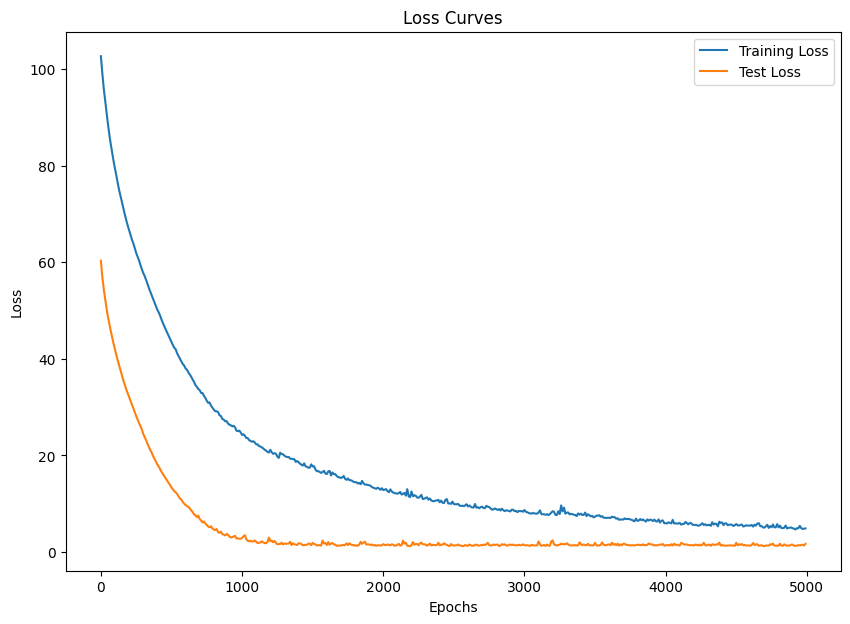

final epoch: 4999 | final train loss: 4.6523 | final test loss: 1.3652


In [ ]:
# @title model_1_1 train/test
training_and_testing_loops(5000, model_1_1, Loss_fn, Optimizer, x_train, y_train, x_test, y_test)

In [ ]:
# @title model_2 declaration
model_2 = LSTM_by_hand(13, 128).to(device)

Optimizer = torch.optim.Adam(model_2.parameters(), lr = 0.005)

Loss_fn = nn.L1Loss()

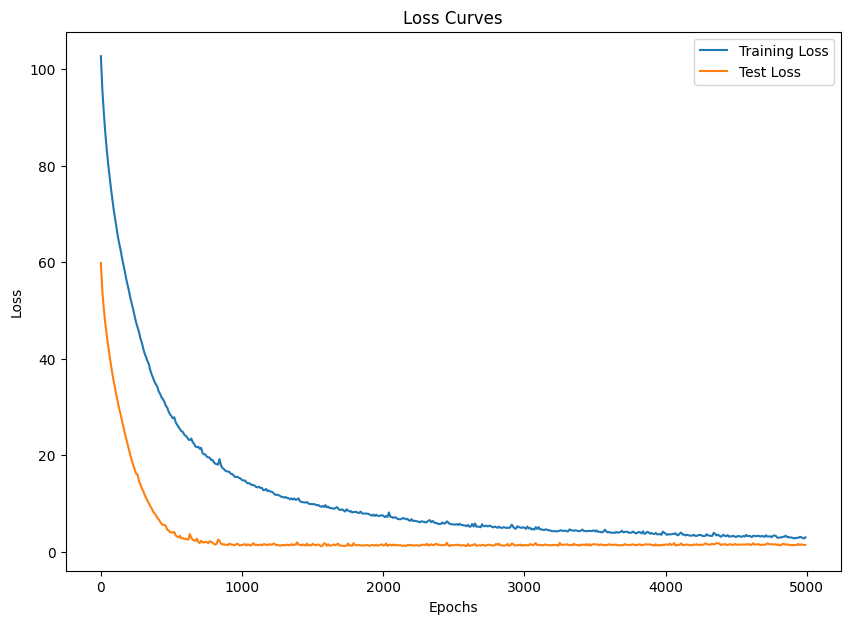

final epoch: 4999 | final train loss: 2.8441 | final test loss: 1.4166


In [ ]:
# @title model_2_0 train/test
training_and_testing_loops(5000, model_2, Loss_fn, Optimizer, x_train, y_train, x_test, y_test)

In [ ]:
# @title model_2_0 declaration
model_2_0 = LSTM_by_hand(13, 128).to(device)

Optimizer = torch.optim.Adam(model_2_0.parameters(), lr = 0.005)

Loss_fn = nn.L1Loss()

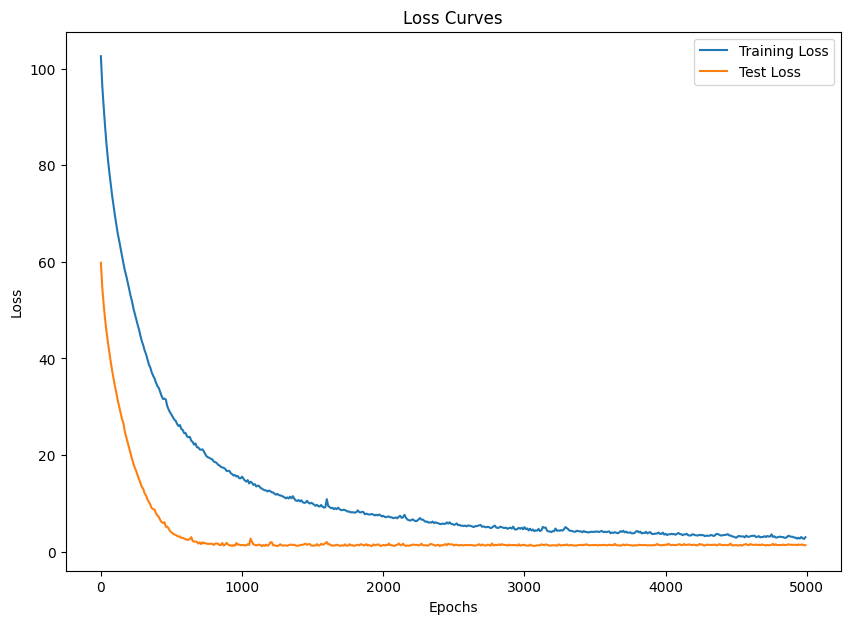

final epoch: 4999 | final train loss: 2.6669 | final test loss: 1.3722


In [ ]:
# @title model_2_0 train/test
training_and_testing_loops(5000, model_2_0, Loss_fn, Optimizer, x_train, y_train, x_test, y_test)

In [ ]:
# @title model_2_1 declaration
model_2_1 = LSTM_by_hand(13, 128).to(device)

Optimizer = torch.optim.Adam(model_2_1.parameters(), lr = 0.005)

Loss_fn = nn.L1Loss()

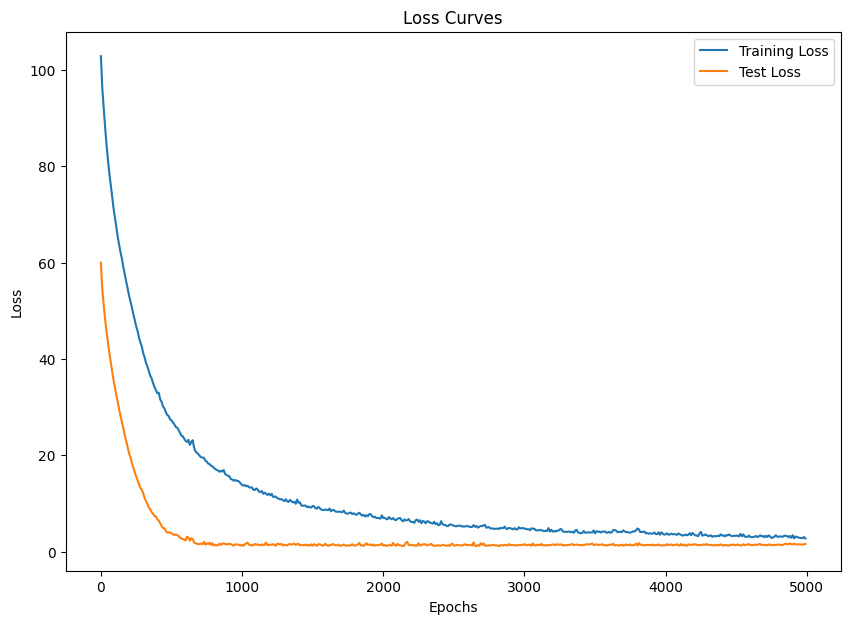

final epoch: 4999 | final train loss: 2.8681 | final test loss: 1.4308


In [ ]:
# @title model_2_1 train/test
training_and_testing_loops(5000, model_2_1, Loss_fn, Optimizer, x_train, y_train, x_test, y_test)

In [ ]:
# save testing set as a .npz file to import for backtesting

# X = np.array(x_test.cpu(), dtype=np.float32)
# y = np.array(y_test.cpu(), dtype=np.float32)

# print("Dataset shape:", X.shape)
# print("Labels shape:", y.shape)

#np.savez("Top_9_S&P500_test_set.npz", X=X, y=y)

In [ ]:
from pathlib import Path
MODEL_PATH = Path("Models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "LSTM_model_1.pth"

MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#chose the model above with the lowest loss and replace model_2_0 with that model
torch.save(obj=model_2_0.state_dict(),
           f=MODEL_SAVE_PATH)